In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[1]
sys.path.append(str(project_root))

import numpy as np
import torch
import matplotlib.pyplot as plt

from pinn.physics.lindblad_1q import LindbladSolver1Q

In [2]:
psi0 = np.array([1, 1], dtype=complex)
psi0 /= np.linalg.norm(psi0)

psi0 = torch.tensor(psi0, dtype=torch.complex64)

rho0 = torch.outer(psi0, psi0.conj()).unsqueeze(0)

print(rho0)
print(rho0.shape)

tensor([[[0.5000+0.j, 0.5000+0.j],
         [0.5000+0.j, 0.5000+0.j]]])
torch.Size([1, 2, 2])


In [3]:
solver = LindbladSolver1Q(
    t1=100,
    t2=100,
    dt=1
)

times, states = solver.run_simulation(
    rho0=rho0,
    time=200
)

print(times.shape)
print(states.shape)

(201,)
(201, 1, 2, 2)


In [4]:
states_np = states[:, 0, :, :]

rho00 = np.real(states_np[:, 0, 0])
rho11 = np.real(states_np[:, 1, 1])
rho01 = np.abs(states_np[:, 0, 1])

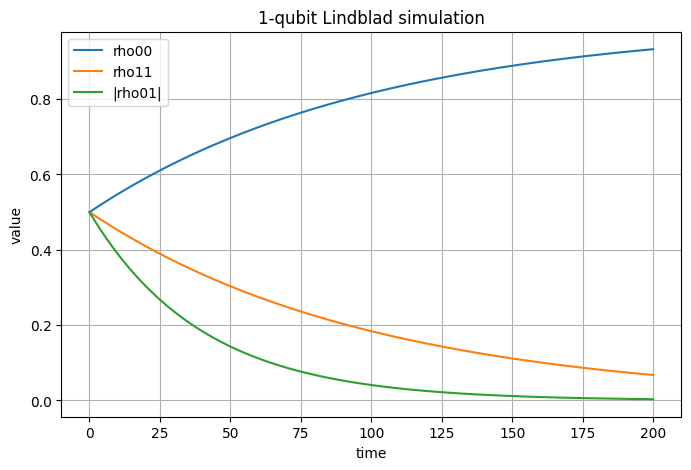

In [5]:
from pinn.utils.plotting import plot_1q_trajectory
plot_1q_trajectory(times, states)

In [7]:
from pinn.models.mlp import build_mlp
from pinn.training.nn_solver_1q import NNSolver1Q

In [8]:
data_indices = np.array([0, 10, 50, 100, 150])

data_times = times[data_indices]
data_values = states[data_indices]

collocation_points = np.sort(
    np.random.uniform(
        np.min(times),
        np.max(times),
        100
    )
)

In [9]:
predictor = build_mlp()

nn_solver = NNSolver1Q(
    predictor=predictor,
    solver=solver,
    data=[data_times, data_values],
    collocation_points=collocation_points
)

In [10]:
test_times = np.linspace(0, 200, 201)

pred = nn_solver.make_predictions(test_times)

print(pred.shape)

(201, 2, 2)


In [11]:
from pinn.training.trainer import Trainer

In [12]:
trainer = Trainer(
    nn_solver=nn_solver,
    epochs=5000,
    learning_rate=1e-3,
    physics_loss=True
)

trainer.train()

Epoch 0 | Data Loss: 14.482965 | Physics Loss: 550.659180
Epoch 1000 | Data Loss: 0.000314 | Physics Loss: 0.001313
Epoch 2000 | Data Loss: 0.000038 | Physics Loss: 0.000301
Epoch 3000 | Data Loss: 0.000010 | Physics Loss: 0.000105
Epoch 4000 | Data Loss: 0.000003 | Physics Loss: 0.000047


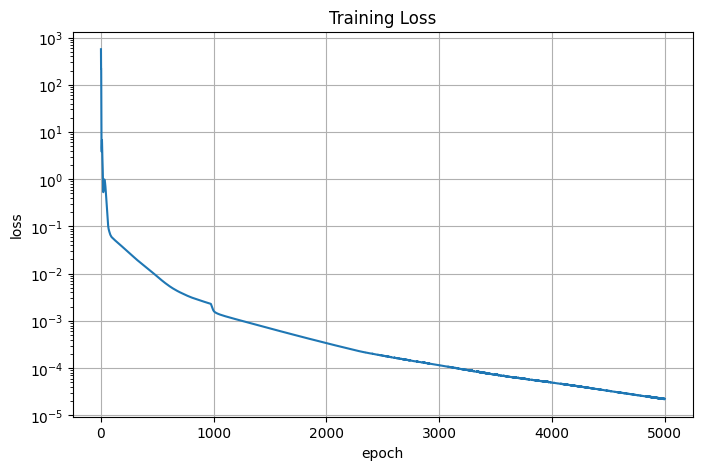

In [13]:
trainer.plot_loss()

In [14]:
test_times = np.linspace(0, 200, 201)

pred_pinn = nn_solver.make_predictions(test_times)

print(pred_pinn.shape)

(201, 2, 2)


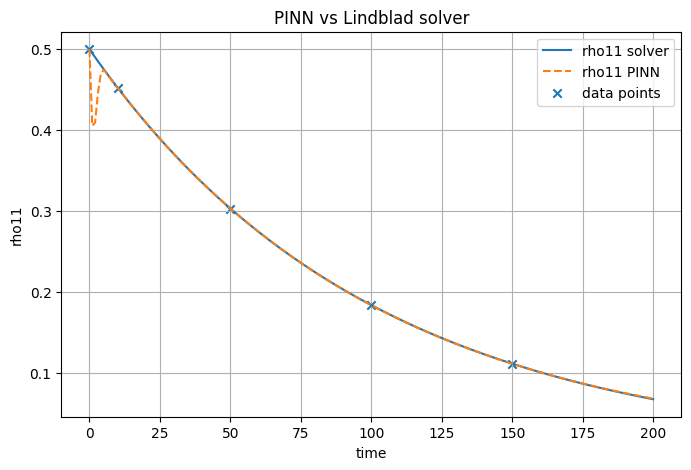

In [15]:
#compare with solver
states_np = states[:, 0, :, :]

plt.figure(figsize=(8, 5))

plt.plot(times, np.real(states_np[:, 1, 1]), label="rho11 solver")
plt.plot(test_times, np.real(pred_pinn[:, 1, 1]), "--", label="rho11 PINN")

plt.scatter(data_times, np.real(data_values[:, 0, 1, 1]), marker="x", label="data points")

plt.xlabel("time")
plt.ylabel("rho11")
plt.title("PINN vs Lindblad solver")
plt.legend()
plt.grid(True)

plt.show()